# Exploratory Data Analysis: SMS Phishing Dataset

Dataset: Mishra & Soni (2022), *SMS Phishing Dataset for Machine Learning and Pattern Recognition*, Mendeley Data, DOI [10.17632/f45bkkt8pr.1](https://doi.org/10.17632/f45bkkt8pr.1), CC BY 4.0.

Run `uv run python -m scamsleuth.data.prepare` first to download and process the data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scamsleuth.data.load import LABELS, download_raw, load_raw
from scamsleuth.data.split import SPLITS

DATA = Path("..") / "data"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
COLORS = {"ham": "#4C78A8", "spam": "#F58518", "smishing": "#E45756"}

## 1. Raw data

Labels in the source file use inconsistent casing (`Smishing` / `smishing`, `Spam` / `spam`); the loader normalises them.

In [2]:
raw_labels = pd.read_csv(download_raw(DATA / "raw"), usecols=["LABEL"])["LABEL"]
raw_labels.value_counts()

LABEL
ham         4844
Smishing     616
spam         466
Spam          23
smishing      22
Name: count, dtype: int64

In [3]:
raw = load_raw(DATA / "raw" / "Dataset_5971.csv")
counts = raw["label"].value_counts().reindex(LABELS)
pd.DataFrame({"messages": counts, "share": (counts / len(raw)).round(3)})

,messages,share
label,,
ham,4844,0.811
spam,489,0.082
smishing,638,0.107


**Class imbalance.** About 81% of messages are `ham`. A model that always predicts `ham` would be ~81% accurate and catch zero scams, which is why accuracy is not the target metric.

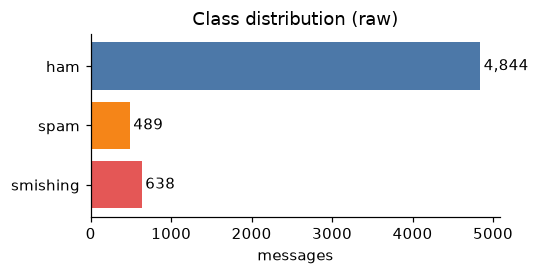

In [4]:
fig, ax = plt.subplots(figsize=(5, 2.6))
ax.barh(counts.index, counts.values, color=[COLORS[label] for label in counts.index])
for i, v in enumerate(counts.values):
    ax.text(v + 40, i, f"{v:,}", va="center")
ax.set_xlabel("messages")
ax.set_title("Class distribution (raw)")
ax.invert_yaxis()
plt.tight_layout()

## 2. Message length

In [5]:
raw["chars"] = raw["text"].str.len()
raw.groupby("label")["chars"].describe()[["mean", "50%", "max"]].reindex(LABELS).round(0)

,mean,50%,max
label,,,
ham,71.0,53.0,910.0
spam,134.0,143.0,379.0
smishing,139.0,146.0,383.0


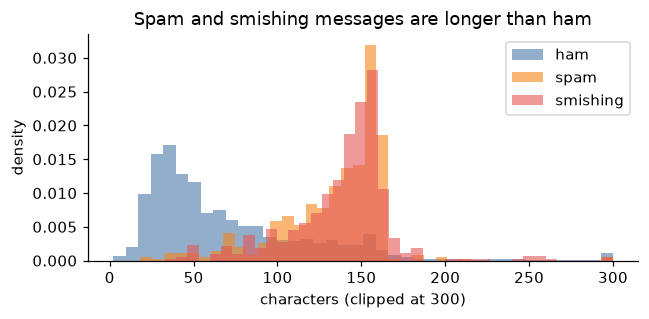

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
for label in LABELS:
    ax.hist(
        raw.loc[raw["label"] == label, "chars"].clip(upper=300),
        bins=40,
        alpha=0.6,
        density=True,
        label=label,
        color=COLORS[label],
    )
ax.set_xlabel("characters (clipped at 300)")
ax.set_ylabel("density")
ax.legend()
ax.set_title("Spam and smishing messages are longer than ham")
plt.tight_layout()

## 3. Links, emails and phone numbers

Share of each class containing the entity, according to the source annotations.

In [7]:
(raw.groupby("label")[["has_url", "has_email", "has_phone"]].mean() * 100).reindex(LABELS).round(1)

,has_url,has_email,has_phone
label,,,
ham,0.2,0.0,0.1
spam,20.2,1.4,63.4
smishing,15.7,1.7,82.6


Phone numbers are a strong signal for spam and smishing, but URLs appear in only a minority of smishing messages here, so a URL-only detector would miss most scams.

## 4. Data quality issues

In [8]:
mojibake = raw["text"].str.contains("\ufffd")
print(f"messages with U+FFFD replacement characters: {mojibake.sum()}")
raw.loc[mojibake, "text"].head(3).tolist()

messages with U+FFFD replacement characters: 145


["What's up? Do you want me to come online? If you are free we can talk sometime�",
 'Please Stay At Home. To encourage the notion of staying at home. All tax-paying citizens are entitled to �305.96 or more emergency refund. smsg.io/fCVbD',
 'Ok lor�whats up�']

The replacement character (`�`) marks a character lost to an encoding error, most often `£` or `€`, sometimes an ellipsis or apostrophe. It is ignored when detecting duplicates.

## 5. Duplicates and leakage

* **Exact duplicates** (identical after lower-casing and removing punctuation) are collapsed. When copies disagree on the label, the majority wins; ties go to the more severe class.
* **Near duplicates** (same template, small edits) are grouped with MinHash LSH (character 5-grams, Jaccard ≥ 0.8) and each group is kept inside a single split.

In [9]:
import json

summary = json.loads((DATA / "processed" / "summary.json").read_text())
summary["dedupe"]

{'rows_in': 5971,
 'rows_out': 5825,
 'duplicate_groups': 139,
 'conflicting_groups': 35}

In [10]:
df = pd.concat(
    [pd.read_parquet(DATA / "processed" / f"{s}.parquet").assign(split=s) for s in SPLITS],
    ignore_index=True,
)
sizes = df["group"].value_counts()
print(
    f"near-duplicate groups: {summary['near_duplicate_groups']} "
    f"covering {summary['rows_in_near_duplicate_groups']} messages"
)
for text in df.loc[df["group"] == sizes.index[1], "text"].head(3):
    print("-", text[:110])

near-duplicate groups: 164 covering 424 messages
- URGENT! We are trying to contact U. Todays draw shows that you have won a £800 prize GUARANTEED. Call 09050001
- URGENT! We are trying to contact U Todays draw shows that you have won a £800 prize GUARANTEED. Call 090500004
- URGENT! We are trying to contact U. Todays draw shows that you have won a £800 prize GUARANTEED. Call 09050003


Without grouping, variants like these would land in both train and test, and the test score would reward memorisation.

## 6. Final splits

In [11]:
table = pd.crosstab(df["split"], df["label"]).reindex(index=list(SPLITS), columns=list(LABELS))
table["total"] = table.sum(axis=1)
table["smishing %"] = (table["smishing"] / table["total"] * 100).round(1)
table

label,ham,spam,smishing,total,smishing %
split,,,,,
train,3449,310,402,4161,9.7
val,690,62,80,832,9.6
test,690,62,80,832,9.6


In [12]:
crossing_groups = (df.groupby("group")["split"].nunique() > 1).sum()
print(f"near-duplicate groups split across train/val/test: {crossing_groups}")

near-duplicate groups split across train/val/test: 0


## Takeaways

1. **Imbalance:** ~81% ham → evaluate smishing recall at a fixed false-alarm rate, not accuracy.
2. **Label noise:** 35 duplicate groups carried conflicting labels, all `spam` vs `smishing`; the boundary between the two classes is fuzzy.
3. **Leakage:** 146 exact duplicates removed and 164 near-duplicate groups kept within one split.
4. **Signals:** phone numbers and message length separate the classes; URLs are less common than expected.
5. **Coverage:** the data is from 2022 and mostly English, so newer scam types need a separate test slice.